In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
import scipy
from scipy.stats import multivariate_normal

In [2]:
import sklearn

In [13]:
def f(chi):
    return np.sqrt((1+np.sqrt(1-chi**2))/2)

In [226]:
sigma = 0.02
N_points = 1000

In [227]:
Mirr = []
chi = []
for i in range(10):
    chii = scipy.stats.uniform.rvs(0, 1, N_points)
    chi = np.append(chi,chii)
    M = norm.rvs(1,sigma,N_points)
    Mirri = M*f(chii)
    Mirr = np.append(Mirr, Mirri)

(array([0.06678294, 0.46748059, 0.76924054, 1.38760111, 2.22362459,
        3.12395757, 5.75075325, 8.79308722, 2.1073728 , 0.04452196]),
 array([0.68629888, 0.72672837, 0.76715786, 0.80758734, 0.84801683,
        0.88844632, 0.9288758 , 0.96930529, 1.00973477, 1.05016426,
        1.09059375]),
 <BarContainer object of 10 artists>)

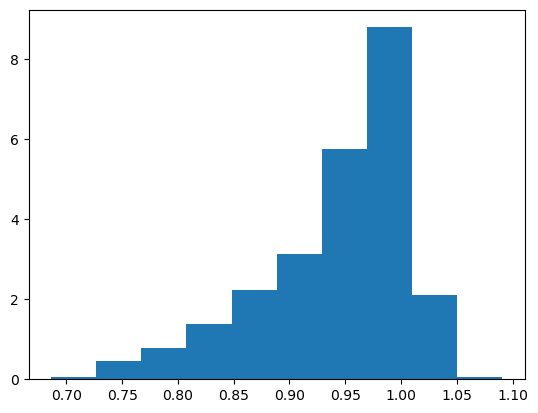

In [228]:
plt.hist(Mirr,density=True)

[]

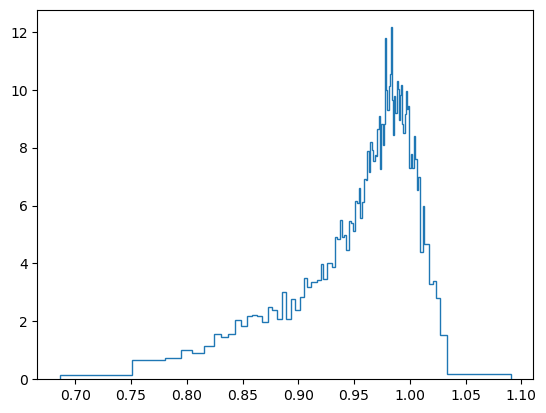

In [229]:
bins100 = np.append(np.sort(Mirr)[::100], np.max(Mirr)) 
#bins30 = np.append(np.sort(Mirr)[::30], np.max(Mirr))
plt.hist(Mirr, bins=bins100, density=True, histtype="step") 
#plt.hist(Mirr, bins=bins30, density=True, histtype="step")
plt.plot()

(array([0.01312278, 0.02624556, 0.02624556, 0.10498224, 0.14435058,
        0.20996448, 0.30182394, 0.3280695 , 0.44617452, 0.68238455,
        0.83985791, 0.57740231, 0.65613899, 0.69550733, 0.91859459,
        0.99733127, 1.06294517, 1.04982239, 1.5616108 , 1.40413745,
        1.8240664 , 1.8896803 , 2.20462702, 2.2833637 , 2.11276756,
        2.16525868, 2.65080153, 2.53269651, 2.88701157, 3.17571273,
        3.63501002, 3.85809728, 4.59297295, 4.85542855, 5.52469033,
        6.31205712, 7.58496676, 8.13612352, 9.94706714, 9.51401541,
        9.31717371, 8.00489572, 5.603427  , 3.83185172, 2.57206485,
        1.19417297, 0.55115675, 0.24933282, 0.11810502, 0.02624556,
        0.01312278, 0.        , 0.        , 0.01312278]),
 array([0.68629888, 0.69391922, 0.70153956, 0.70915989, 0.71678023,
        0.72440057, 0.7320209 , 0.73964124, 0.74726158, 0.75488191,
        0.76250225, 0.77012259, 0.77774292, 0.78536326, 0.7929836 ,
        0.80060393, 0.80822427, 0.81584461, 0.82346494, 0.

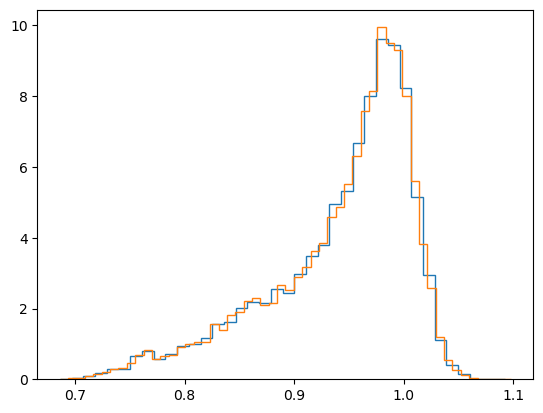

In [230]:
import astropy.visualization.hist
astropy.visualization.hist(Mirr, bins="scott", histtype="step",density=True)
astropy.visualization.hist(Mirr, bins="freedman", histtype="step",density=True)

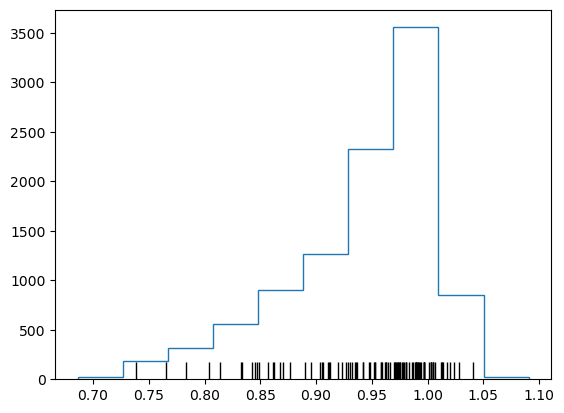

In [231]:
plt.hist(Mirr,histtype="step")
plt.plot(Mirr[:100], 0*Mirr[:100], '|', color='k', markersize=25);

In [232]:
from sklearn.neighbors import KernelDensity

In [233]:
xgrid = np.linspace(Mirr.min(),Mirr.max(),10000)

In [234]:
def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

[]

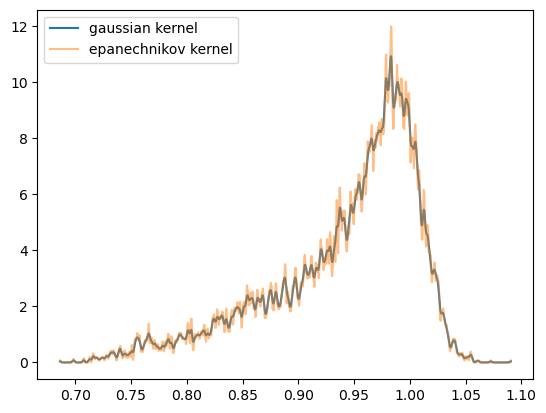

In [235]:
PDFtophat = kde_sklearn(Mirr,bandwidth=0.001,kernel="gaussian") 
plt.plot(xgrid,PDFtophat,label='gaussian kernel',alpha = 1)
PDFtophat = kde_sklearn(Mirr,bandwidth=0.001,kernel="epanechnikov") 
plt.plot(xgrid,PDFtophat,label='epanechnikov kernel',alpha = 0.5)
plt.legend()
plt.plot()

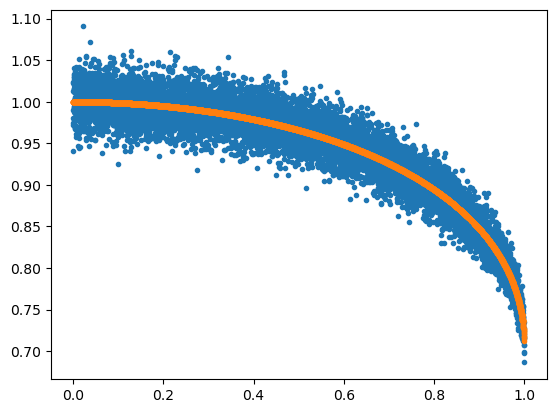

In [236]:
plt.scatter(chi,Mirr,marker='.')
plt.scatter(chi,f(chi),marker='.')

In [237]:
print(stats.ks_2samp(Mirr,f(chi)))

KstestResult(statistic=0.157, pvalue=6.501778763346037e-108, statistic_location=0.999999999020541, statistic_sign=-1)


In [238]:
N_sigma = 30
sigmas= np.logspace(-5,1,N_sigma)
sigmas

array([1.00000000e-05, 1.61026203e-05, 2.59294380e-05, 4.17531894e-05,
       6.72335754e-05, 1.08263673e-04, 1.74332882e-04, 2.80721620e-04,
       4.52035366e-04, 7.27895384e-04, 1.17210230e-03, 1.88739182e-03,
       3.03919538e-03, 4.89390092e-03, 7.88046282e-03, 1.26896100e-02,
       2.04335972e-02, 3.29034456e-02, 5.29831691e-02, 8.53167852e-02,
       1.37382380e-01, 2.21221629e-01, 3.56224789e-01, 5.73615251e-01,
       9.23670857e-01, 1.48735211e+00, 2.39502662e+00, 3.85662042e+00,
       6.21016942e+00, 1.00000000e+01])

/tmp/ipykernel_63018/1844867091.py:10: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  KSs_f = np.append(KSs_f, stats.ks_2samp(Mirri,f(chi))[1])


Text(0.5, 0, '$M_{irr}$')

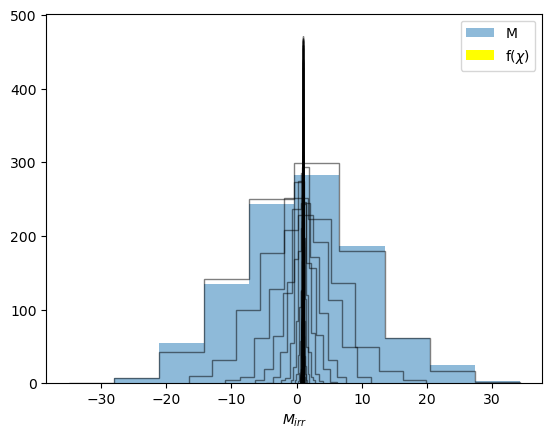

In [239]:
KSs_f = []
KSs_M = []

for i in range(N_sigma):
    chi = scipy.stats.uniform.rvs(0, 1, N_points)
    M = norm.rvs(1,sigmas[i],N_points)
    Mirri = M*f(chi)
    plt.hist(Mirri,histtype="step",color='k',alpha=0.5)
    
    KSs_f = np.append(KSs_f, stats.ks_2samp(Mirri,f(chi))[1])
    KSs_M = np.append(KSs_M, stats.ks_2samp(Mirri,M)[1])

plt.hist(M,alpha=0.5,label='M')
plt.hist(f(chi),alpha=1,color='yellow',label=r'f($\chi$)')
plt.legend()
plt.xlabel(r'$M_{irr}$')

Text(0, 0.5, 'KS M$_{irr}$-f')

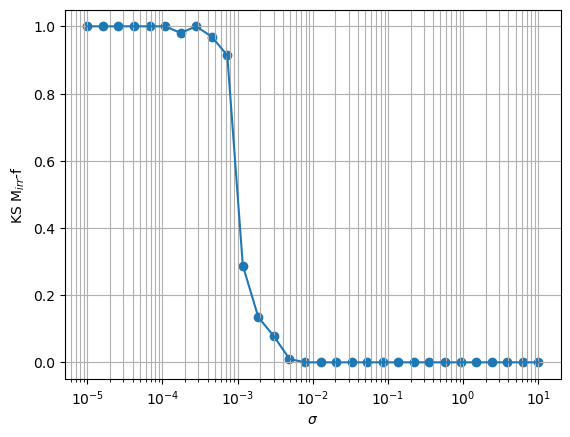

In [240]:
plt.grid(which='both')
plt.plot(sigmas, KSs_f)
plt.scatter(sigmas, KSs_f)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel(r'$\sigma$')
plt.ylabel(r'KS M$_{irr}$-f')


Text(0, 0.5, 'KS M$_{irr}$-M')

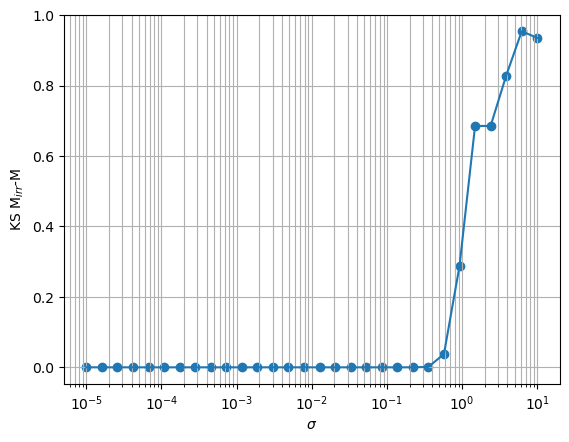

In [241]:
plt.grid(which='both')
plt.plot(sigmas, KSs_M)
plt.scatter(sigmas, KSs_M)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel(r'$\sigma$')
plt.ylabel(r'KS M$_{irr}$-M')

In [244]:
from tqdm.notebook import tqdm

In [271]:
def p_f(f):
    return 2*(2*f**2-1)/np.sqrt(1-f**2)
def integrand(f,x):
    return ((2/np.pi)**0.5 / sigma ) * np.exp(-(x/f -1)**2 /(2*sigma**2)) * (2*f**2-1)/(1 - f**2)**0.5 / f
def p_Mirr(f,x):
    return [scipy.integrate.quad(lambda f: integrand(f,xt), 1/2**0.5,1)[0] for xt in tqdm(x)]

N = 10000
x = np.linspace(min(1-5*sigma,1/np.sqrt(2)),1+5*sigma,N)

Mirr_from_int = [scipy.integrate.quad(lambda f: integrand(f,xt), 1/2**0.5,1)[0] for xt in tqdm(x)]

  0%|          | 0/10000 [00:00<?, ?it/s]

[]

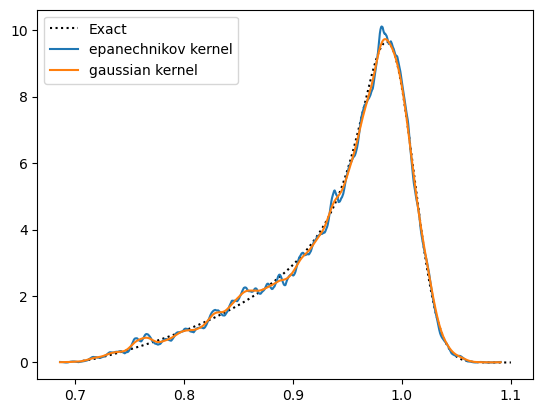

In [283]:
plt.plot(x,Mirr_from_int,label='Exact',c='black',ls=':')
PDFtophat = kde_sklearn(Mirr,bandwidth=0.005,kernel="epanechnikov") 
plt.plot(xgrid,PDFtophat,label='epanechnikov kernel',alpha = 1)
PDFtophat = kde_sklearn(Mirr,bandwidth=0.005,kernel="gaussian") 
plt.plot(xgrid,PDFtophat,label='gaussian kernel',alpha = 1)

plt.legend()
plt.plot()